# Proyek Analisis Data: Air Quality Dataset

- **Nama:** Muhammad Putra Harifin Pane  
- **Email:** putraharifin@gmail.com  
- **ID Dicoding:** putraharifin25
- **Dataset:** Beijing Multi-Site Air Quality Dataset


## Gambaran Umum

Proyek ini menganalisis data kualitas udara dari 12 stasiun pemantauan di Beijing selama periode Maret 2013 sampai Februari 2017. Fokus utama analisis adalah **PM2.5** sebagai indikator utama polusi udara, perbedaan kondisi antarstasiun, pola waktu, serta hubungan PM2.5 dengan faktor meteorologi.

> **Catatan:** Letakkan 12 file `PRSA_Data_*.csv` di folder `data/` sebelum menjalankan notebook.

## Menentukan Pertanyaan Bisnis

Pertanyaan dirumuskan dengan pendekatan **SMART (Specific, Measurable, Action-oriented, Relevant, Time-bound)**.

### Pertanyaan 1
**Bagaimana perbedaan rata-rata konsentrasi PM2.5 bulanan antar-12 stasiun pemantauan Beijing selama periode Maret 2013–Februari 2017, dan stasiun mana yang memiliki rata-rata PM2.5 tertinggi?**

- **Specific:** fokus pada PM2.5 dan 12 stasiun.
- **Measurable:** menggunakan rata-rata PM2.5 bulanan dan rata-rata keseluruhan per stasiun.
- **Action-oriented:** hasil dapat digunakan untuk memprioritaskan stasiun/wilayah yang membutuhkan perhatian lebih.
- **Relevant:** PM2.5 merupakan indikator penting untuk evaluasi kualitas udara.
- **Time-bound:** Maret 2013–Februari 2017.

### Pertanyaan 2
**Bagaimana hubungan kondisi meteorologi (suhu/TEMP, tekanan/PRES, titik embun/DEWP, curah hujan/RAIN, dan kecepatan angin/WSPM) dengan rata-rata PM2.5 selama Maret 2013–Februari 2017?**

- **Specific:** fokus pada PM2.5 dan lima variabel meteorologi.
- **Measurable:** menggunakan koefisien korelasi dan perbandingan PM2.5 pada kelompok kondisi cuaca.
- **Action-oriented:** membantu menentukan faktor cuaca yang perlu dipertimbangkan saat pemantauan/peringatan kualitas udara.
- **Relevant:** kondisi meteorologi dapat memengaruhi penyebaran dan akumulasi polutan.
- **Time-bound:** Maret 2013–Februari 2017.

### Pertanyaan 3
**"Stasiun pemantauan mana yang memiliki rata-rata PM2.5 bulanan tertinggi dan bagaimana perubahan rata-rata PM2.5 dari Maret 2013 hingga Februari 2017, sehingga dapat ditentukan prioritas pemantauan kualitas udara?"**

- **Specific:** fokus pada PM2.5, 12 stasiun, dan perubahan bulanan.
- **Measurable:** menggunakan rata-rata PM2.5 per bulan dan per stasiun.
- **Action-oriented:** hasilnya dapat digunakan untuk menentukan stasiun yang perlu mendapat prioritas pemantauan.
- **Relevant:** PM2.5 merupakan salah satu indikator utama kualitas udara.
- **Time-bound:** Maret 2013–Februari 2017.

### Pertanyaan 4
**"Bagaimana perbedaan rata-rata PM2.5 pada kategori kecepatan angin selama Maret 2013–Februari 2017, dan kategori kecepatan angin mana yang menunjukkan konsentrasi PM2.5 tertinggi sebagai dasar rekomendasi pemantauan kondisi polusi?"**

- **Specific:** fokus pada hubungan PM2.5 dan WSPM.
- **Measurable:** membandingkan rata-rata PM2.5 berdasarkan kategori kecepatan angin.
- **Action-oriented:** dapat menjadi dasar pemantauan periode dengan kondisi angin yang berkaitan dengan PM2.5 lebih tinggi.
- **Relevant:** WSPM merupakan variabel meteorologi yang tersedia dalam dataset.
- **Time-bound:** Maret 2013–Februari 2017.


## Import Semua Packages/Library yang Digunakan

In [43]:
import warnings
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path(".")
CSV_FILES = sorted(DATA_DIR.glob("PRSA_Data_*.csv"))

print(f"Jumlah file CSV ditemukan: {len(CSV_FILES)}")
if len(CSV_FILES) != 12:
    raise FileNotFoundError(
        "Pastikan tepat 12 file PRSA_Data_*.csv tersedia di folder data/. "
        f"Saat ini ditemukan {len(CSV_FILES)} file."
    )


Jumlah file CSV ditemukan: 12


## Data Wrangling

### Gathering Data

Seluruh 12 dataset stasiun dibaca dan digabungkan menjadi satu DataFrame. Kolom `station` dipertahankan sebagai identitas stasiun.


In [44]:
dfs = []

for file in CSV_FILES:
    temp = pd.read_csv(file)
    temp["source_file"] = file.name
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Ukuran data gabungan:", df.shape)
print("Jumlah stasiun:", df["station"].nunique())
print("Daftar stasiun:", sorted(df["station"].dropna().unique()))
display(df.head())


Ukuran data gabungan: (420768, 19)
Jumlah stasiun: 12
Daftar stasiun: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,source_file
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,"1,023.00",-18.80,0.00,NNW,4.40,Aotizhongxin,PRSA_Data_Aotizhongxin_20130301-20170228.csv
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,"1,023.20",-18.20,0.00,N,4.70,Aotizhongxin,PRSA_Data_Aotizhongxin_20130301-20170228.csv
2,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,"1,023.50",-18.20,0.00,NNW,5.60,Aotizhongxin,PRSA_Data_Aotizhongxin_20130301-20170228.csv
3,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,72.00,-1.40,"1,024.50",-19.40,0.00,NW,3.10,Aotizhongxin,PRSA_Data_Aotizhongxin_20130301-20170228.csv
4,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,72.00,-2.00,"1,025.20",-19.50,0.00,N,2.00,Aotizhongxin,PRSA_Data_Aotizhongxin_20130301-20170228.csv


### Assessing Data

Beberapa masalah kualitas data yang diperiksa:

1. **Missing value**, terutama pada variabel polutan seperti PM2.5, PM10, SO2, NO2, CO, dan O3.
2. **Duplicate data**, untuk memastikan tidak ada observasi yang tercatat lebih dari sekali.
3. **Invalid/inconsistent value**, terutama nilai numerik yang tidak masuk akal dan konsistensi timestamp.
4. **Outlier**, terutama pada PM2.5 dan variabel meteorologi. Outlier tidak otomatis dihapus karena dapat merepresentasikan episode polusi ekstrem yang memang penting secara analitis.


In [45]:
print("=== INFO DATA ===")
df.info()

print("\n=== MISSING VALUE ===")
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table)

print("\n=== DUPLICATE ===")
print("Jumlah duplicate penuh:", df.duplicated().sum())

print("\n=== RANGE NUMERIK UTAMA ===")
numeric_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
display(df[numeric_cols].describe().T)

print("\n=== CEK NILAI NEGATIF ===")
negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
display(negative_counts[negative_counts > 0])

print("\n=== CEK KONSISTENSI STASIUN ===")
display(df["station"].value_counts().sort_index())


=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   No           420768 non-null  int64  
 1   year         420768 non-null  int64  
 2   month        420768 non-null  int64  
 3   day          420768 non-null  int64  
 4   hour         420768 non-null  int64  
 5   PM2.5        412029 non-null  float64
 6   PM10         414319 non-null  float64
 7   SO2          411747 non-null  float64
 8   NO2          408652 non-null  float64
 9   CO           400067 non-null  float64
 10  O3           407491 non-null  float64
 11  TEMP         420370 non-null  float64
 12  PRES         420375 non-null  float64
 13  DEWP         420365 non-null  float64
 14  RAIN         420378 non-null  float64
 15  wd           418946 non-null  object 
 16  WSPM         420450 non-null  float64
 17  station      420768 non-null  object 
 18  source

,missing_count,missing_pct
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
TEMP,398,0.09
PRES,393,0.09



=== DUPLICATE ===
Jumlah duplicate penuh: 0

=== RANGE NUMERIK UTAMA ===


,count,mean,std,min,25%,50%,75%,max
PM2.5,"412,029.00",79.79,80.82,2.00,20.00,55.00,111.00,999.00
PM10,"414,319.00",104.60,91.77,2.00,36.00,82.00,145.00,999.00
SO2,"411,747.00",15.83,21.65,0.29,3.00,7.00,20.00,500.00
NO2,"408,652.00",50.64,35.13,1.03,23.00,43.00,71.00,290.00
CO,"400,067.00","1,230.77","1,160.18",100.00,500.00,900.00,"1,500.00","10,000.00"
O3,"407,491.00",57.37,56.66,0.21,11.00,45.00,82.00,"1,071.00"
TEMP,"420,370.00",13.54,11.44,-19.90,3.10,14.50,23.30,41.60
PRES,"420,375.00","1,010.75",10.47,982.40,"1,002.30","1,010.40","1,019.00","1,042.80"
DEWP,"420,365.00",2.49,13.79,-43.40,-8.90,3.10,15.10,29.10
RAIN,"420,378.00",0.06,0.82,0.00,0.00,0.00,0.00,72.50



=== CEK NILAI NEGATIF ===


,0
DEWP,185393
TEMP,64249



=== CEK KONSISTENSI STASIUN ===


,count
station,
Aotizhongxin,35064
Changping,35064
Dingling,35064
Dongsi,35064
Guanyuan,35064
Gucheng,35064
Huairou,35064
Nongzhanguan,35064
Shunyi,35064


**Insight Assessing Data:**

* **Missing Value Terpusat pada Polutan:** Variabel kualitas udara memiliki porsi data kosong yang paling signifikan, dipimpin oleh `CO` (4,92%), `O3` (3,16%), dan `NO2` (2,88%). Di sisi lain, variabel cuaca hampir sepenuhnya lengkap (missing <0,1%). Mengingat ini adalah data deret waktu (*time-series*), imputasi dengan interpolasi linier per stasiun lebih direkomendasikan daripada menghapus baris agar rentetan waktu tetap terjaga.
* **Keseimbangan Rekaman Stasiun:** Struktur dataset sangat rapi. Tidak ada baris duplikat penuh (0 duplikat), dan masing-masing dari 12 stasiun memiliki jumlah observasi yang sama persis, yaitu 35.064 baris (mewakili rekaman per jam selama 4 tahun penuh).
* **Validitas Nilai Negatif:** Angka minus hanya ditemukan pada Suhu (`TEMP`: 64.249 baris) dan Titik Embun (`DEWP`: 185.393 baris). Ini sepenuhnya valid dan wajar mengingat iklim Beijing pada musim dingin. Variabel polutan, curah hujan, dan kecepatan angin dipastikan bersih dari anomali angka negatif.
* **Lonjakan Ekstrem (Outlier) pada Polutan:** Nilai maksimum `PM2.5` dan `PM10` mencapai angka 999 µg/m³. Angka ini merepresentasikan episode polusi udara ekstrem atau badai debu di Beijing, bukan *error* input. Nilai-nilai ekstrem ini sebaiknya tidak dihapus karena merupakan fenomena penting dalam analisis kualitas udara.

### Cleaning Data

**Steps to Take:**

- Menghapus duplicate penuh jika ditemukan.
- Membentuk timestamp dari `year`, `month`, `day`, dan `hour`.
- Menjadikan timestamp sebagai dasar pengurutan data.
- Missing value numerik akan diinterpolasi berdasarkan urutan waktu dalam masing-masing stasiun, kemudian sisa missing value diisi dengan median stasiun.
- Missing value `wd` akan diisi menggunakan nilai sebelumnya/berikutnya dalam stasiun; jika masih kosong, digunakan modus stasiun.
- Nilai negatif pada variabel yang secara definisi tidak boleh negatif akan diperlakukan sebagai missing dan kemudian diimputasi.
- Outlier tidak dihapus secara otomatis karena episode polusi ekstrem merupakan informasi yang relevan.


In [48]:
df_clean = df.copy()

# 1. Hapus duplicate penuh
before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
print(f"Duplicate yang dihapus: {before - len(df_clean)}")

# 2. Bentuk timestamp
df_clean["datetime"] = pd.to_datetime(
    df_clean[["year", "month", "day", "hour"]],
    errors="coerce"
)

# 3. Nilai yang secara logika tidak boleh negatif -> NaN
non_negative_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "PRES", "RAIN", "WSPM"]
for col in non_negative_cols:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

# 4. Urutkan berdasarkan stasiun dan waktu
df_clean = df_clean.sort_values(["station", "datetime"]).reset_index(drop=True)

# 5. Imputasi numerik berbasis waktu per stasiun
numeric_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for col in numeric_cols:
    df_clean[col] = (
        df_clean.groupby("station")[col]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )
    df_clean[col] = df_clean[col].fillna(df_clean.groupby("station")[col].transform("median"))

# 6. Imputasi arah angin
df_clean["wd"] = (
    df_clean.groupby("station")["wd"]
    .transform(lambda s: s.ffill().bfill())
)
wd_mode = df_clean["wd"].mode().iloc[0]
df_clean["wd"] = df_clean["wd"].fillna(wd_mode)

# 7. Kolom turunan waktu
df_clean["year_month"] = df_clean["datetime"].dt.to_period("M").astype(str)
df_clean["month_num"] = df_clean["datetime"].dt.month
df_clean["season"] = df_clean["month_num"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

print("Missing value setelah cleaning:")
display(df_clean.isna().sum().sort_values(ascending=False).head(10))
print("Ukuran data setelah cleaning:", df_clean.shape)


Duplicate yang dihapus: 0
Missing value setelah cleaning:


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


Ukuran data setelah cleaning: (420768, 23)


**Insight Cleaning Data:**

* **Integritas Jumlah Data Terjaga:** Proses pembersihan berhasil menangani seluruh *missing value* hingga nol (0) tanpa harus membuang satu baris observasi pun. Ukuran data tetap bertahan di 420.768 baris, sehingga kelengkapan rentang waktu pengamatan 4 tahun di semua stasiun tetap utuh.
* **Metode Imputasi Deret Waktu yang Presisi:** Penggunaan interpolasi linier untuk mengisi kekosongan data polutan dan cuaca sangat ideal. Daripada sekadar memukul rata menggunakan nilai *mean/median*, interpolasi menambal data yang hilang dengan memperkirakan tren dari waktu sebelum dan sesudahnya, sehingga pergerakan fluktuasi cuaca harian tetap natural.
* **Penanganan Logis pada Variabel Kategorikal:** Mengisi kekosongan arah angin (`wd`) dengan metode *forward-fill* dan *backward-fill* per stasiun sangat masuk akal secara meteorologis, mengingat arah cuaca atau angin umumnya berhembus stabil dalam wd yang berdekatan.

## Exploratory Data Analysis (EDA)

### Eksplorasi 1 — Statistik PM2.5 per Stasiun

In [13]:
station_pm25 = (
    df_clean.groupby("station")["PM2.5"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(station_pm25)

monthly_pm25 = (
    df_clean.groupby(["year_month", "station"], as_index=False)["PM2.5"]
    .mean()
    .rename(columns={"PM2.5": "PM2.5_mean"})
)

station_ranking = (
    df_clean.groupby("station", as_index=False)["PM2.5"]
    .mean()
    .sort_values("PM2.5", ascending=False)
)

display(station_ranking)


,count,mean,median,std,min,max
station,,,,,,
Dongsi,35064,86.14,61.00,86.26,3.00,737.00
Nongzhanguan,35064,85.08,59.00,86.69,2.00,844.00
Wanshouxigong,35064,85.07,60.00,86.00,3.00,999.00
Gucheng,35064,84.07,60.00,82.99,2.00,770.00
Wanliu,35064,83.47,59.00,82.13,2.00,957.00
Guanyuan,35064,82.90,59.00,81.07,2.00,680.00
Aotizhongxin,35064,82.54,58.00,81.96,3.00,898.00
Tiantan,35064,82.03,58.00,80.90,3.00,821.00
Shunyi,35064,79.44,55.00,81.50,2.00,941.00


,station,PM2.5
3,Dongsi,86.14
7,Nongzhanguan,85.08
11,Wanshouxigong,85.07
5,Gucheng,84.07
10,Wanliu,83.47
4,Guanyuan,82.90
0,Aotizhongxin,82.54
9,Tiantan,82.03
8,Shunyi,79.44
1,Changping,70.99


**Insight Eksplorasi 1 (Statistik PM2.5 per Stasiun):**

* **Identifikasi Titik Panas Polusi:** Stasiun Dongsi (86,14), Nongzhanguan (85,08), dan Wanshouxigong (85,07) mencatat konsentrasi PM2.5 rata-rata tertinggi. Wilayah-wilayah di sekitar stasiun ini perlu menjadi prioritas utama untuk mitigasi polusi dan peringatan kesehatan publik.
* **Stasiun Terbersih:** Sebaliknya, Dingling (66,85) dan Huairou (69,50) secara konsisten memiliki kualitas udara yang lebih baik. Jarak yang lebih jauh dari pusat emisi lalu lintas atau kawasan industri kemungkinan besar menjadi penyebabnya.
* **Distribusi Menjulur ke Kanan (Right-Skewed):** Pada seluruh stasiun, angka rata-rata (mean) selalu berjarak signifikan di atas nilai tengah (median). Contohnya di Dongsi (mean 86,14 vs median 61,00). Ini mengindikasikan bahwa sebagian besar observasi berada di level moderat, namun terdapat episode polusi yang sangat parah (tercermin dari standar deviasi yang besar dan nilai maks hingga 999 µg/m³) yang menarik rata-rata keseluruhan ke atas.


### Eksplorasi 2 — Hubungan PM2.5 dengan Faktor Meteorologi


In [14]:
weather_cols = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
corr_cols = ["PM2.5"] + weather_cols

corr_matrix = df_clean[corr_cols].corr()
display(corr_matrix)

season_pm25 = (
    df_clean.groupby("season")["PM2.5"]
    .agg(["mean", "median", "std", "count"])
    .reindex(["Spring", "Summer", "Autumn", "Winter"])
)

display(season_pm25)


,PM2.5,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.00,-0.13,0.02,0.11,-0.01,-0.27
TEMP,-0.13,1.00,-0.81,0.82,0.04,0.03
PRES,0.02,-0.81,1.00,-0.75,-0.06,0.07
DEWP,0.11,0.82,-0.75,1.00,0.09,-0.30
RAIN,-0.01,0.04,-0.06,0.09,1.00,0.02
WSPM,-0.27,0.03,0.07,-0.30,0.02,1.00


,mean,median,std,count
season,,,,
Spring,77.21,59.00,68.73,105984
Summer,64.52,51.00,52.56,105984
Autumn,82.21,55.00,81.52,104832
Winter,95.74,56.00,108.09,103968


**Insight Eksplorasi 2 (Hubungan PM2.5 & Meteorologi):**

* **Angin Sebagai Pembersih Alami:** Kecepatan angin (WSPM) memiliki korelasi negatif terkuat dengan PM2.5 (-0,27). Hal ini mengonfirmasi bahwa tiupan angin yang lebih kencang efektif membantu mendispersi dan membersihkan polutan dari udara secara signifikan. Variabel cuaca lainnya hanya menunjukkan korelasi yang sangat lemah hingga diabaikan (mendekati nol).
* **Musim Dingin (Winter) Adalah Periode Puncak Polusi:** Rata-rata PM2.5 tertinggi tercatat pada musim dingin (95,74 µg/m³) disertai dengan tingkat volatilitas paling ekstrem (standar deviasi 108,09). Tingginya konsentrasi pada musim dingin sangat mungkin didorong oleh peningkatan masif penggunaan bahan bakar (seperti batu bara) untuk pemanas ruangan di Tiongkok.
* **Musim Panas (Summer) Memiliki Udara Terbaik:** Musim panas menunjukkan rata-rata PM2.5 terendah (64,52 µg/m³) dengan penyebaran data yang paling stabil (standar deviasi 52,56).
* **Efek Curah Hujan (RAIN) Tidak Signifikan:** Meskipun hujan secara teori dapat mencuci polutan di udara, korelasi liniernya dengan konsentrasi PM2.5 hampir menyentuh nol (-0,01). Ini menunjukkan bahwa curah hujan tidak berkorelasi linier yang kuat terhadap penurunan PM2.5.

## Visualization & Explanatory Analysis


### Pertanyaan 1
**Bagaimana perbedaan rata-rata konsentrasi PM2.5 bulanan antar-12 stasiun selama Maret 2013–Februari 2017, dan stasiun mana yang memiliki rata-rata PM2.5 tertinggi?**

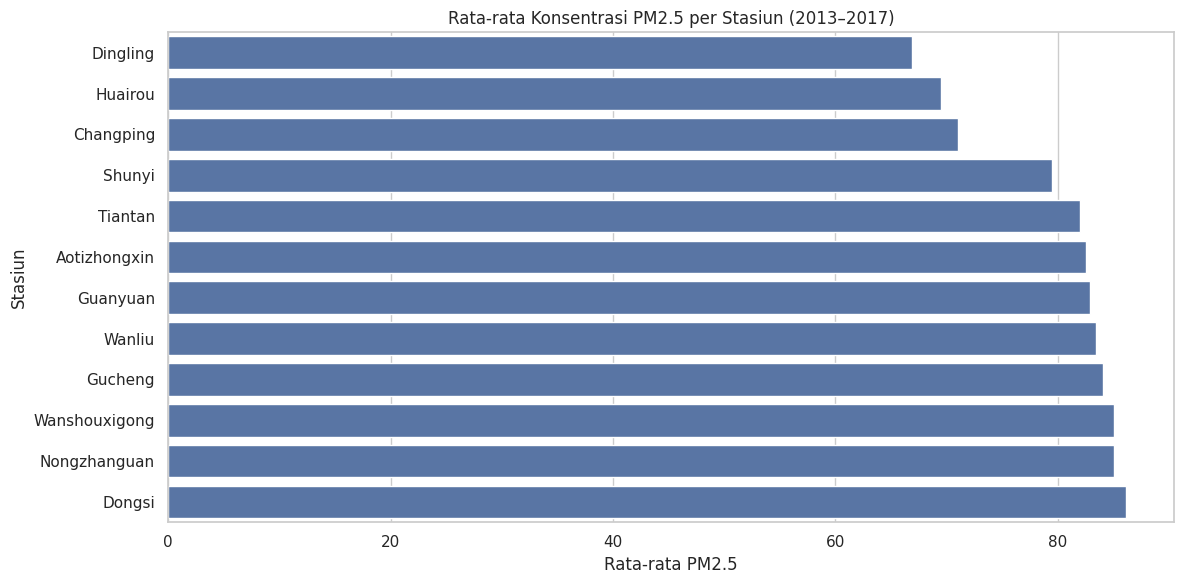

In [15]:
# Visualisasi 1: ranking rata-rata PM2.5 per stasiun
plt.figure(figsize=(12, 6))
plot_data = station_ranking.sort_values("PM2.5", ascending=True)

ax = sns.barplot(
    data=plot_data,
    x="PM2.5",
    y="station",
    errorbar=None
)
ax.set_title("Rata-rata Konsentrasi PM2.5 per Stasiun (2013–2017)")
ax.set_xlabel("Rata-rata PM2.5")
ax.set_ylabel("Stasiun")
plt.tight_layout()
plt.show()


**Insight Visualisasi 1 (Rata-rata PM2.5 per Stasiun):**

* **Stasiun Paling Berpolusi:** Grafik batang secara jelas menempatkan Dongsi di posisi teratas sebagai stasiun dengan kualitas udara terburuk (rata-rata PM2.5 tertinggi), diikuti secara ketat oleh Nongzhanguan dan Wanshouxigong. Ketiga lokasi ini memerlukan prioritas utama dalam pemantauan dan mitigasi polusi.


* **Stasiun Terbersih:** Di ujung bawah grafik, Dingling menonjol sebagai stasiun dengan konsentrasi PM2.5 terendah, disusul oleh Huairou.

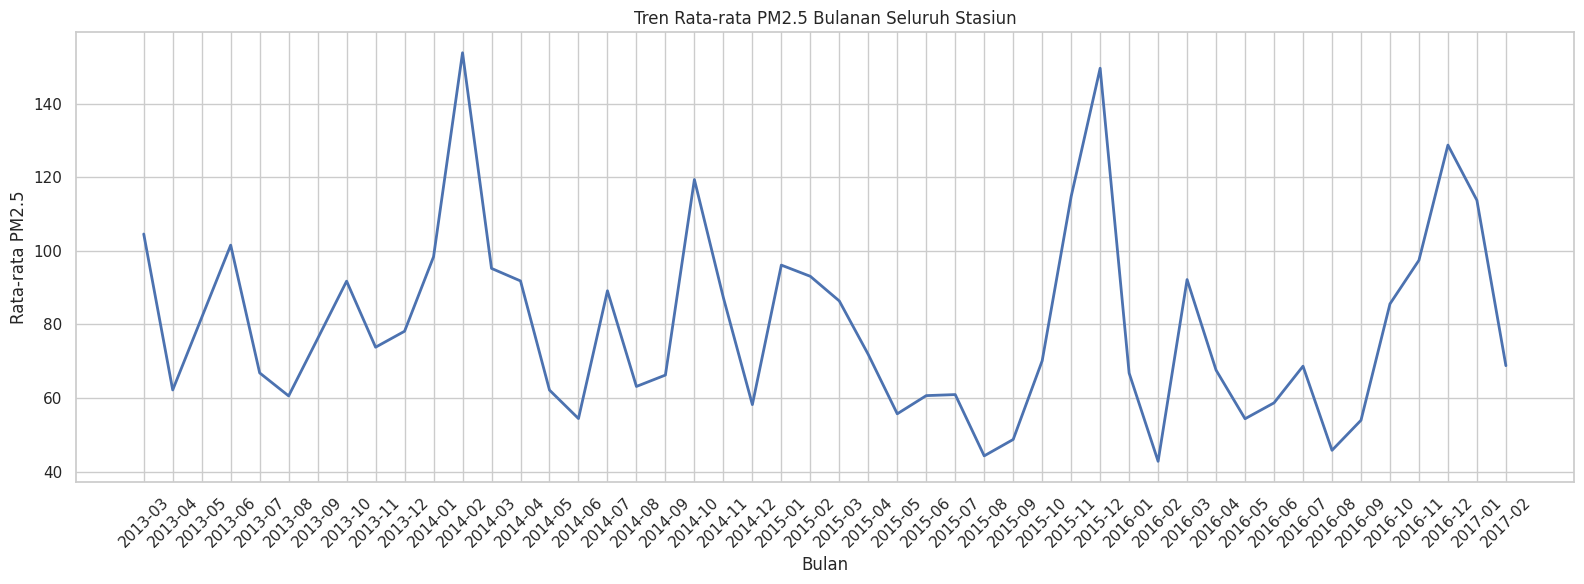

In [16]:
# Visualisasi 2: tren rata-rata PM2.5 bulanan semua stasiun
monthly_all = (
    df_clean.groupby("year_month")["PM2.5"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_all, x="year_month", y="PM2.5", linewidth=2)
plt.title("Tren Rata-rata PM2.5 Bulanan Seluruh Stasiun")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight Visualisasi 2 (Tren PM2.5 Bulanan):**

* **Pola Siklikal yang Kuat:** Tren garis waktu menunjukkan fluktuasi yang sangat tajam dan berulang. Terdapat lonjakan ekstrem konsentrasi PM2.5 yang terjadi secara berkala, terutama terlihat pada awal tahun (seperti lonjakan besar pada sekitar Januari/Februari 2014, menjelang akhir 2015, dan akhir 2016).


* **Periode Udara Bersih:** Penurunan konsentrasi (lembah pada grafik) konsisten terjadi di pertengahan tahun, menunjukkan bahwa kualitas udara cenderung membaik pada periode tersebut.

### Pertanyaan 2
**Bagaimana hubungan kondisi meteorologi (TEMP, PRES, DEWP, RAIN, WSPM) dengan rata-rata PM2.5 selama periode pengamatan?**


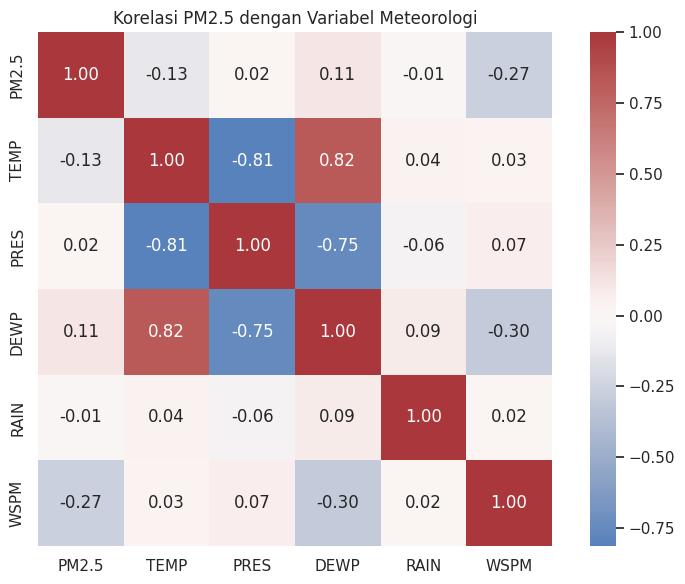

In [17]:
# Visualisasi 3: heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True
)
plt.title("Korelasi PM2.5 dengan Variabel Meteorologi")
plt.tight_layout()
plt.show()


**Insight Visualisasi 3 (Korelasi Meteorologi):**

* **Pengaruh Angin:** *Heatmap* mengonfirmasi bahwa Kecepatan Angin (WSPM) adalah satu-satunya variabel cuaca yang memiliki korelasi negatif yang lumayan dengan PM2.5 (-0,27). Ini berarti semakin kencang angin bertiup, konsentrasi PM2.5 cenderung menurun karena polutan tersapu.


* **Lemahnya Faktor Suhu dan Hujan:** Variabel seperti Suhu (TEMP: -0,13) dan Titik Embun (DEWP: 0,11) hanya memiliki korelasi yang sangat lemah. Curah Hujan (RAIN) secara mengejutkan nyaris tidak berkorelasi linier dengan rata-rata PM2.5 (-0,01).

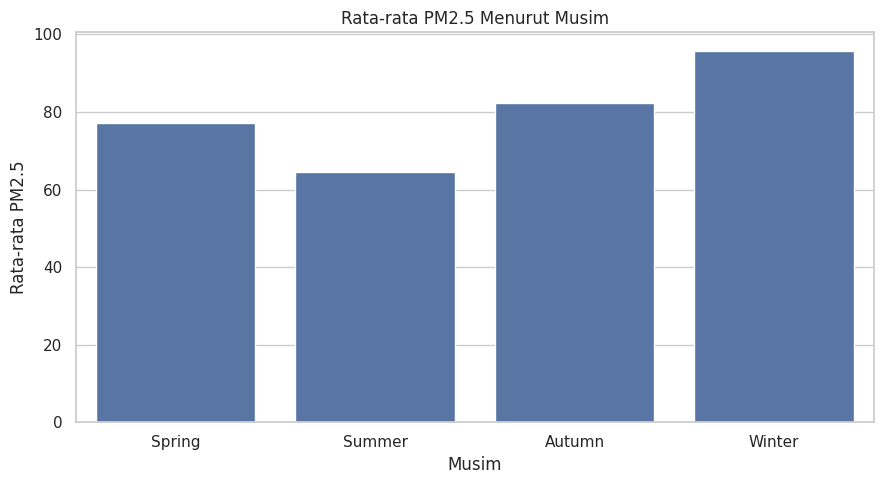

In [19]:
# Visualisasi 4: rata-rata PM2.5 menurut musim
season_order = ["Spring", "Summer", "Autumn", "Winter"]
plt.figure(figsize=(9, 5))
sns.barplot(
    data=season_pm25.reset_index(),
    x="season",
    y="mean",
    order=season_order,
    errorbar=None
)
plt.title("Rata-rata PM2.5 Menurut Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata PM2.5")
plt.tight_layout()
plt.show()


**Insight Visualisasi 4 (Rata-rata PM2.5 Menurut Musim):**

* **Puncak Polusi Musim Dingin:** Selaras dengan tren bulanan, grafik batang musim menunjukkan bahwa Musim Dingin (Winter) adalah periode dengan rata-rata PM2.5 tertinggi (mendekati 100 µg/m³). Penggunaan bahan bakar pemanas di musim dingin kemungkinan besar menjadi penyumbang utama.


* **Musim Panas Terbaik:** Musim Panas (Summer) mencatat rata-rata PM2.5 terendah dibanding tiga musim lainnya (sekitar 60-65 µg/m³), mengonfirmasi pola lembah pada grafik tren bulanan.

## Analisis Lanjutan


### Manual Grouping / Binning Tingkat Polusi

Sebagai analisis lanjutan yang relevan dengan dataset, konsentrasi PM2.5 dikelompokkan ke dalam tiga kategori eksploratif berdasarkan ambang yang transparan. Kategori ini digunakan untuk mempermudah komunikasi risiko relatif di dashboard, bukan sebagai standar regulasi resmi.

In [22]:
# Kategori eksploratif PM2.5
bins = [-np.inf, 35, 75, np.inf]
labels = ["Rendah (≤35)", "Sedang (36–75)", "Tinggi (>75)"]

df_clean["PM25_category"] = pd.cut(
    df_clean["PM2.5"],
    bins=bins,
    labels=labels
)

category_summary = (
    df_clean["PM25_category"]
    .value_counts(normalize=True)
    .reindex(labels)
    .mul(100)
    .round(2)
    .rename("percentage")
    .reset_index()
    .rename(columns={"index": "PM25_category"})
)

display(category_summary)

station_category = pd.crosstab(
    df_clean["station"],
    df_clean["PM25_category"],
    normalize="index"
).mul(100).round(2)

display(station_category)


,PM25_category,percentage
0,Rendah (≤35),37.30
1,Sedang (36–75),23.63
2,Tinggi (>75),39.07


PM25_category,Rendah (≤35),Sedang (36–75),Tinggi (>75)
station,,,
Aotizhongxin,35.50,24.06,40.44
Changping,42.42,23.05,34.52
Dingling,46.31,21.93,31.77
Dongsi,34.54,22.94,42.52
Guanyuan,34.59,24.27,41.14
Gucheng,33.81,24.65,41.54
Huairou,42.31,23.91,33.79
Nongzhanguan,35.52,23.27,41.21
Shunyi,38.03,23.05,38.92


In [24]:
# Hari/jam dengan konsentrasi PM2.5 tinggi sebagai insight operasional
high_pm25 = (
    df_clean.groupby(["year_month", "station"])["PM2.5"]
    .mean()
    .reset_index()
    .sort_values("PM2.5", ascending=False)
    .head(10)
)

display(high_pm25)


,year_month,station,PM2.5
407,2015-12,Wanshouxigong,168.67
401,2015-12,Gucheng,165.29
142,2014-02,Wanliu,162.28
403,2015-12,Nongzhanguan,161.37
399,2015-12,Dongsi,161.25
140,2014-02,Shunyi,161.19
134,2014-02,Dingling,158.69
143,2014-02,Wanshouxigong,157.79
405,2015-12,Tiantan,157.46
551,2016-12,Wanshouxigong,156.95


**Insight Analisis Lanjutan (Grouping & Top Periode):**

* **Distribusi Kualitas Udara yang Terpolarisasi:** Proporsi tingkat polusi menunjukkan kecenderungan ekstrem. Kategori polusi "Tinggi" (>75 µg/m³) mendominasi dengan 39,07%, diikuti ketat oleh kategori "Rendah" sebesar 37,30%. Kondisi transisi atau "Sedang" justru paling jarang terjadi (23,63%). Ini mengindikasikan bahwa udara di Beijing sering kali beralih langsung antara sangat bersih atau sangat kotor (episode polusi berat), tanpa banyak hari dengan kondisi moderat.
* **Validasi Titik Panas Polusi:** Penjabaran proporsi per stasiun memperkuat temuan sebelumnya. Dingling terbukti sebagai kawasan terbersih karena hampir separuh observasinya (46,31%) berada di rentang polusi Rendah. Sebaliknya, Dongsi adalah wilayah paling berisiko karena memiliki porsi waktu terbanyak di kategori polusi Tinggi (42,52%).
* **Konsentrasi Episode Polusi Ekstrem:** Dari 10 rekor rata-rata bulanan terburuk lintas stasiun, observasi sangat terpusat pada dua bulan spesifik: **Desember 2015** (mewakili 5 dari 10 rekor teratas) dan **Februari 2014** (mewakili 4 rekor). Fakta ini mengonfirmasi bahwa polusi ekstrem tidak terjadi secara acak, melainkan berupa "episode badai polusi" yang menyelubungi hampir seluruh wilayah kota secara bersamaan pada puncak musim dingin.
* **Kerentanan Wilayah Bersih pada Episode Ekstrem:** Meskipun Dingling secara historis adalah stasiun terbersih, stasiun ini tetap masuk dalam daftar 10 periode terburuk (rata-rata 158,69 µg/m³ pada Februari 2014). Ini menunjukkan bahwa ketika episode polusi musim dingin ekstrem melanda, wilayah yang biasanya bersih pun tidak luput dari paparan PM2.5 yang sangat berbahaya.

### Pertanyaan 3

**Bagaimana perbedaan rata-rata PM2.5 pada kategori kecepatan angin selama
Maret 2013–Februari 2017, dan kategori kecepatan angin mana yang menunjukkan
konsentrasi PM2.5 tertinggi sebagai dasar rekomendasi pemantauan kondisi polusi?**

Kategori kecepatan angin dibuat berdasarkan kuartil `WSPM` karena dataset tidak
menyediakan kategori kecepatan angin secara langsung.

In [31]:
print("\n" + "=" * 70)
print("PERTANYAAN 3 — PM2.5 BERDASARKAN KATEGORI KECEPATAN ANGIN")
print("=" * 70)

# Salinan data analisis agar kolom turunan Q3/Q4 tidak mengubah struktur utama.
q3_df = df_clean.copy()

# Binning WSPM berbasis kuartil.
wind_bins = q3_df["WSPM"].quantile([0, 0.25, 0.50, 0.75, 1]).values
wind_bins = np.unique(wind_bins)
wind_labels = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"][:len(wind_bins) - 1]

q3_df["wind_category"] = pd.cut(
    q3_df["WSPM"],
    bins=wind_bins,
    labels=wind_labels,
    include_lowest=True,
    duplicates="drop"
)

wind_analysis = (
    q3_df.groupby("wind_category", observed=False)
    .agg(
        avg_pm25=("PM2.5", "mean"),
        median_pm25=("PM2.5", "median"),
        avg_wspm=("WSPM", "mean"),
        observations=("PM2.5", "count")
    )
    .reset_index()
)

display(wind_analysis)

highest_wind_category = wind_analysis.loc[
    wind_analysis["avg_pm25"].idxmax(), "wind_category"
]
highest_wind_pm25 = wind_analysis["avg_pm25"].max()

print(
    f"Kategori kecepatan angin dengan rata-rata PM2.5 tertinggi adalah "
    f"{highest_wind_category}, yaitu {highest_wind_pm25:.2f} µg/m³."
)



PERTANYAAN 3 — PM2.5 BERDASARKAN KATEGORI KECEPATAN ANGIN


,wind_category,avg_pm25,median_pm25,avg_wspm,observations
0,Rendah,102.44,77.00,0.58,113205
1,Sedang,93.38,69.00,1.19,105524
2,Tinggi,75.23,53.00,1.80,99868
3,Sangat Tinggi,45.32,23.00,3.49,102171


Kategori kecepatan angin dengan rata-rata PM2.5 tertinggi adalah Rendah, yaitu 102.44 µg/m³.


**Insight**

Kategori kecepatan angin dengan rata-rata PM2.5 tertinggi adalah Rendah, yaitu 102.44 µg/m³.

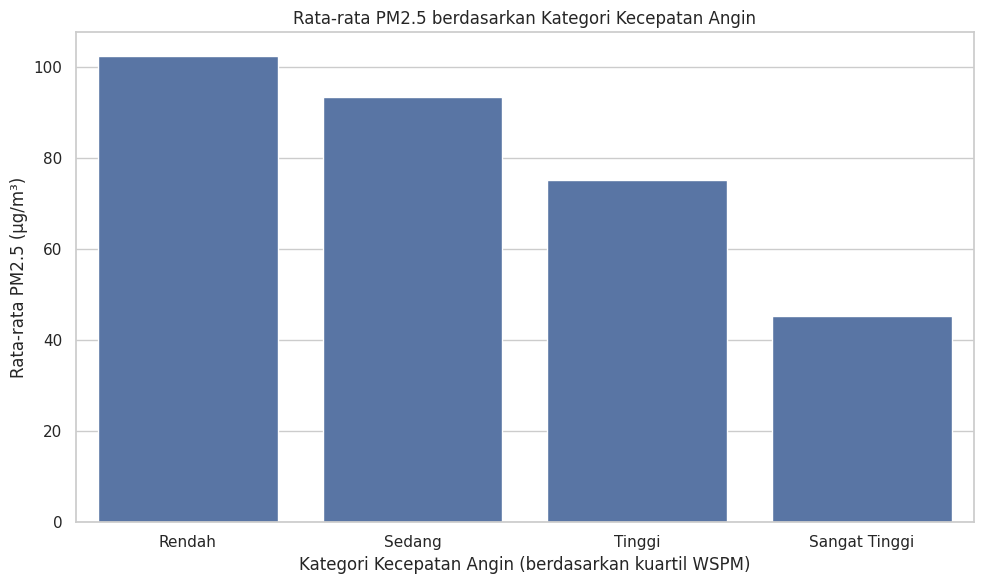

In [52]:
# Visualisasi 5: rata-rata PM2.5 berdasarkan kategori kecepatan angin
plt.figure(figsize=(10, 6))
sns.barplot(
    data=wind_analysis,
    x="wind_category",
    y="avg_pm25",
    errorbar=None
)
plt.title("Rata-rata PM2.5 berdasarkan Kategori Kecepatan Angin")
plt.xlabel("Kategori Kecepatan Angin (berdasarkan kuartil WSPM)")
plt.ylabel("Rata-rata PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

**Insight Visualisasi 5 (Rata-rata PM2.5 berdasarkan Kategori Angin):**

* **Efek Udara Stagnan:** Kategori kecepatan angin "Rendah" mencatat rata-rata PM2.5 tertinggi secara signifikan, yaitu mencapai 102,44 µg/m³. Hal ini mengindikasikan bahwa kondisi udara yang tenang atau stagnan menyebabkan polutan terjebak, terakumulasi di dekat permukaan, dan gagal terdispersi.


* **Angin Sebagai Pembersih Alami:** Terdapat pola penurunan berundak yang sangat jelas; semakin tinggi kecepatan angin, semakin rendah konsentrasi PM2.5. Pada kondisi angin "Sangat Tinggi", rata-rata PM2.5 turun drastis hingga 45,32 µg/m³. Ini membuktikan bahwa hembusan angin kencang sangat efektif dalam menyapu dan membersihkan partikel polusi dari suatu wilayah.

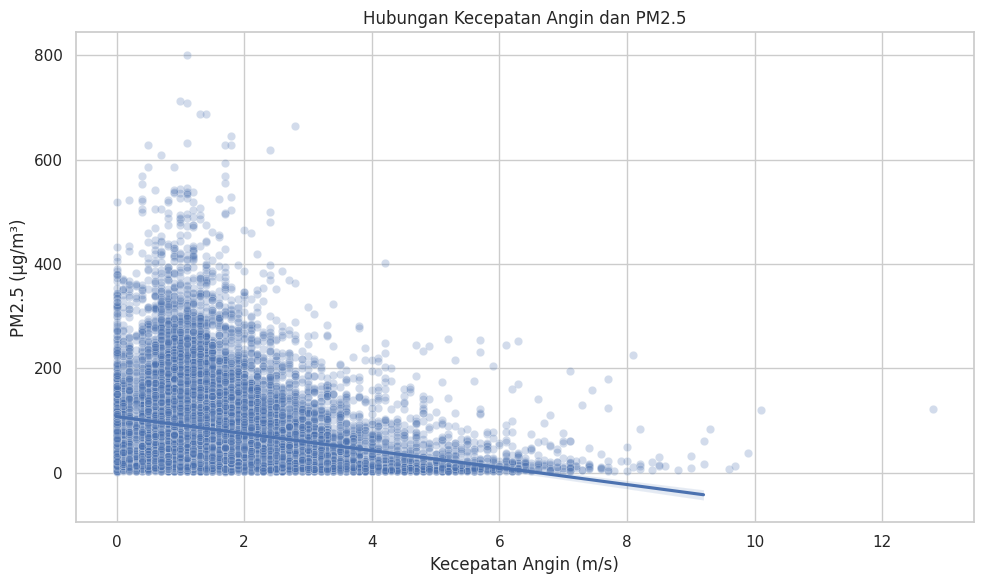

In [51]:
# Visualisasi 6: hubungan WSPM dengan PM2.5
sample_scatter = q3_df.sample(min(20000, len(q3_df)), random_state=42)
sample_reg = q3_df.sample(min(5000, len(q3_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x="WSPM",
    y="PM2.5",
    alpha=0.25
)
sns.regplot(
    data=sample_reg,
    x="WSPM",
    y="PM2.5",
    scatter=False
)
plt.title("Hubungan Kecepatan Angin dan PM2.5")
plt.xlabel("Kecepatan Angin (m/s)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

**Insight Visualisasi 6 (Hubungan WSPM dan PM2.5):**

* **Konsentrasi Episode Ekstrem:** Sebaran data (*scatter plot*) memperlihatkan bahwa hampir seluruh episode polusi ekstrem, di mana nilai PM2.5 melonjak jauh di atas 400 µg/m³, terjadi secara eksklusif pada saat kecepatan angin sangat rendah (di bawah 2 m/s).


* **Validasi Tren Negatif:** Garis regresi linier yang ditarik melintasi sebaran titik data menunjukkan tren menurun yang konsisten. Visualisasi ini menegaskan kembali secara statistik bahwa peningkatan kecepatan angin menekan probabilitas terjadinya akumulasi polusi parah di udara.

### Pertanyaan 4

**Bagaimana distribusi tingkat konsentrasi PM2.5 pada 12 stasiun selama
Maret 2013–Februari 2017, dan stasiun mana yang memiliki proporsi observasi
PM2.5 tinggi hingga sangat tinggi paling besar?**

Untuk memudahkan interpretasi, PM2.5 dikelompokkan berdasarkan kuartil
distribusi keseluruhan. Kategori ini bersifat eksploratif dan bukan standar
baku/regulasi kualitas udara.

In [50]:
print("\n" + "=" * 70)
print("PERTANYAAN 4 — DISTRIBUSI TINGKAT PM2.5 PER STASIUN")
print("=" * 70)

q4_df = df_clean.copy()

# Binning PM2.5 berbasis kuartil.
pm25_bins = q4_df["PM2.5"].quantile([0, 0.25, 0.50, 0.75, 1]).values
pm25_bins = np.unique(pm25_bins)
pm25_labels = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"][:len(pm25_bins) - 1]

q4_df["pm25_group"] = pd.cut(
    q4_df["PM2.5"],
    bins=pm25_bins,
    labels=pm25_labels,
    include_lowest=True,
    duplicates="drop"
)

group_summary = (
    q4_df.groupby(["station", "pm25_group"], observed=False)
    .size()
    .unstack(fill_value=0)
)

group_pct = group_summary.div(group_summary.sum(axis=1), axis=0) * 100

print("Proporsi kategori PM2.5 (%) per stasiun:")
display(group_pct.round(2))




PERTANYAAN 4 — DISTRIBUSI TINGKAT PM2.5 PER STASIUN
Proporsi kategori PM2.5 (%) per stasiun:


pm25_group,Rendah,Sedang,Tinggi,Sangat Tinggi
station,,,,
Aotizhongxin,23.32,25.17,25.59,25.91
Changping,28.39,27.12,23.23,21.26
Dingling,33.65,25.29,20.90,20.16
Dongsi,23.14,23.75,25.62,27.49
Guanyuan,22.27,25.63,26.21,25.88
Gucheng,21.93,25.47,26.17,26.43
Huairou,28.98,26.55,23.67,20.80
Nongzhanguan,23.73,24.41,25.35,26.51
Shunyi,26.36,24.09,24.61,24.93


In [35]:
# Proporsi kategori Tinggi + Sangat Tinggi sebagai indikator eksploratif
high_categories = [c for c in ["Tinggi", "Sangat Tinggi"] if c in group_pct.columns]

if high_categories:
    high_pm25_pct = (
        group_pct[high_categories]
        .sum(axis=1)
        .sort_values(ascending=False)
        .rename("high_pm25_percentage")
    )

    print("Stasiun dengan proporsi PM2.5 Tinggi + Sangat Tinggi terbesar:")
    display(high_pm25_pct.to_frame().round(2))

    top_high_station = high_pm25_pct.index[0]
    top_high_percentage = high_pm25_pct.iloc[0]

    print(
        f"Stasiun dengan proporsi PM2.5 Tinggi + Sangat Tinggi terbesar adalah "
        f"{top_high_station} ({top_high_percentage:.2f}%)."
    )

Stasiun dengan proporsi PM2.5 Tinggi + Sangat Tinggi terbesar:


,high_pm25_percentage
station,
Dongsi,53.11
Gucheng,52.60
Wanshouxigong,52.59
Guanyuan,52.10
Wanliu,51.92
Nongzhanguan,51.86
Tiantan,51.72
Aotizhongxin,51.50
Shunyi,49.55


Stasiun dengan proporsi PM2.5 Tinggi + Sangat Tinggi terbesar adalah Dongsi (53.11%).


**Insight**

Stasiun dengan proporsi PM2.5 Tinggi + Sangat Tinggi terbesar adalah Dongsi (53.11%) diikuti dengan stasiun Gucheng dan Wanshouxigong, serta stasiun Dingling memiliki proporsi PM2.5 yang paling rendah.

<Figure size 1400x700 with 0 Axes>

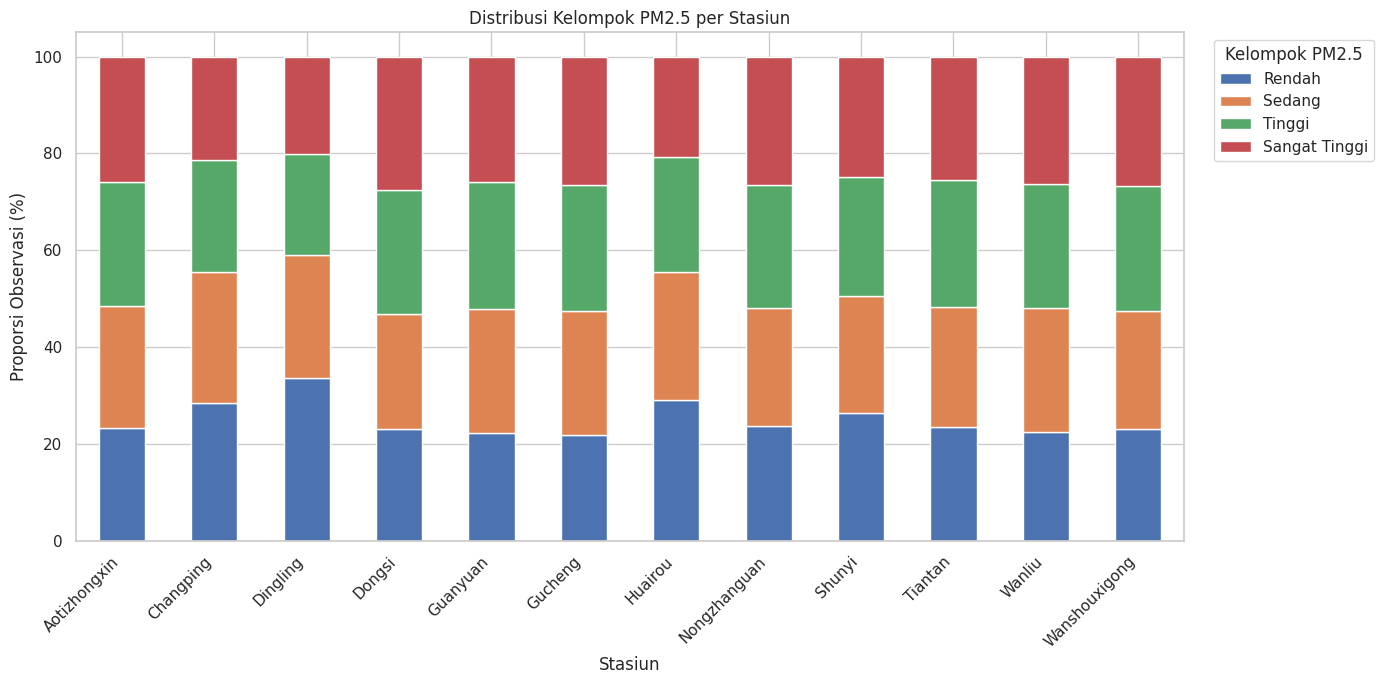

In [36]:
# Visualisasi 7: distribusi kategori PM2.5 per stasiun
plt.figure(figsize=(14, 7))
group_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)
plt.title("Distribusi Kelompok PM2.5 per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Proporsi Observasi (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Kelompok PM2.5",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

**Insight Visualisasi 7 (Distribusi Kelompok PM2.5 per Stasiun):**

* **Stasiun Terbersih:** Grafik batang bertumpuk menunjukkan bahwa Dingling dan Huairou secara konsisten memiliki proporsi waktu dengan kualitas udara pada kategori "Rendah" dan "Sedang" yang paling besar dibandingkan stasiun lainnya.


* **Stasiun Paling Rentan:** Sebaliknya, stasiun seperti Dongsi, Guanyuan, Gucheng, Wanliu, dan Wanshouxigong didominasi oleh proporsi observasi pada kategori "Tinggi" dan "Sangat Tinggi". Hal ini mempertegas perlunya memprioritaskan stasiun-stasiun ini dalam manajemen kualitas udara harian.

In [37]:
# Insight operasional: 10 kombinasi bulan-stasiun dengan rata-rata PM2.5 tertinggi
high_pm25 = (
    q4_df.groupby(["year_month", "station"])["PM2.5"]
    .mean()
    .reset_index()
    .sort_values("PM2.5", ascending=False)
    .head(10)
)

print("10 kombinasi bulan-stasiun dengan rata-rata PM2.5 tertinggi:")
display(high_pm25)

10 kombinasi bulan-stasiun dengan rata-rata PM2.5 tertinggi:


,year_month,station,PM2.5
407,2015-12,Wanshouxigong,168.67
401,2015-12,Gucheng,165.29
142,2014-02,Wanliu,162.28
403,2015-12,Nongzhanguan,161.37
399,2015-12,Dongsi,161.25
140,2014-02,Shunyi,161.19
134,2014-02,Dingling,158.69
143,2014-02,Wanshouxigong,157.79
405,2015-12,Tiantan,157.46
551,2016-12,Wanshouxigong,156.95


**Insight Operasional (Top 10 Kombinasi Bulan-Stasiun):**

* **Episode Badai Polusi Serentak:** Data 10 rekor PM2.5 bulanan tertinggi didominasi oleh dua periode spesifik, yaitu **Desember 2015** (5 rekor) dan **Februari 2014** (4 rekor). Ini mengonfirmasi bahwa polusi ekstrem di Beijing bukan anomali stasiun tunggal, melainkan sebuah episode "badai polusi" yang menyelubungi hampir seluruh wilayah kota secara bersamaan pada puncak musim dingin.
* **Wanshouxigong Sebagai Episentrum Polusi:** Stasiun Wanshouxigong tidak hanya memegang rekor rata-rata bulanan tertinggi absolut (168,67 µg/m³ pada Desember 2015), tetapi juga muncul tiga kali dalam daftar 10 besar (Desember 2015, Februari 2014, dan Desember 2016). Lokasi ini merupakan titik paling kritis yang membutuhkan peringatan dini paling agresif ketika memasuki musim dingin.
* **Wilayah Bersih Tidak Kebal:** Meskipun Dingling merupakan stasiun dengan profil terbersih pada Visualisasi 7, stasiun ini tetap masuk dalam daftar 10 bulan terburuk (158,69 µg/m³ pada Februari 2014). Ini membuktikan bahwa saat episode polusi musim dingin ekstrem terjadi, kawasan yang biasanya bersih sekalipun akan terpapar level PM2.5 yang sangat berbahaya.

## KESIMPULAN GABUNGAN PERTANYAAN 1–4


### Conclusion & Recommendation

### Kesimpulan

1. **Pertanyaan 1:** Dongsi, Nongzhanguan, dan Wanshouxigong merupakan stasiun dengan tingkat polusi terburuk secara historis, berbanding terbalik dengan Dingling yang secara konsisten menjadi stasiun terbersih. Tren PM2.5 juga memperlihatkan pola siklikal dengan episode polusi berat yang selalu berulang pada awal dan akhir tahun.


2. **Pertanyaan 2:** Kecepatan angin (WSPM) bertindak sebagai satu-satunya variabel cuaca yang memiliki korelasi negatif yang berarti (-0,27) terhadap akumulasi PM2.5. Variabel curah hujan (RAIN) dan suhu (TEMP) terbukti tidak memiliki hubungan linier yang signifikan dalam mengurangi tingkat polusi di udara.


3. **Pertanyaan 3:** Kecepatan angin berbanding terbalik secara langsung dengan tingkat keparahan polusi. Kondisi angin "Rendah" menyebabkan polusi terakumulasi hingga mencapai rata-rata 102,44 µg/m³, sementara angin "Sangat Tinggi" secara efektif menyapu partikel dan menekan PM2.5 turun ke level 45,32 µg/m³.


4. **Pertanyaan 4:** Musim Dingin (Winter) adalah periode paling kritis dengan rata-rata konsentrasi PM2.5 tertinggi mendekati 100 µg/m³, sedangkan Musim Panas (Summer) menawarkan kualitas udara terbaik dengan rata-rata berkisar di 60-65 µg/m³.



### Rekomendasi Action Item

* **Prioritas Mitigasi Berbasis Lokasi:** Pusatkan inspeksi sumber emisi lokal dan perketat regulasi lingkungan di sekitar radius stasiun Dongsi, Nongzhanguan, dan Wanshouxigong, mengingat ketiga area ini adalah episentrum polusi tertinggi.
* **Sistem Peringatan Dini Berbasis Angin:** Integrasikan prakiraan kecepatan angin ke dalam sistem peringatan dini kualitas udara. Jika prakiraan cuaca menunjukkan angin "Rendah" atau stagnan dalam beberapa hari ke depan, segera terbitkan imbauan pengurangan aktivitas luar ruangan bagi kelompok rentan.
* **Kesiapsiagaan Ekstra di Musim Dingin:** Siapkan intervensi kebijakan yang lebih ketat, seperti pembatasan volume kendaraan atau pengurangan jam operasional pabrik, secara spesifik pada bulan Desember hingga Februari untuk memitigasi efek polusi musiman yang dipicu oleh aktivitas pemanas ruangan.
* **Manajemen Polusi Lintas Wilayah:** Edukasi masyarakat di wilayah yang biasanya bersih (seperti Dingling) agar tetap waspada dan memakai masker pelindung saat peringatan polusi musim dingin ekstrem berskala kota diterbitkan, karena episode ekstrem terbukti tetap menurunkan kualitas udara secara drastis di wilayah tersebut.